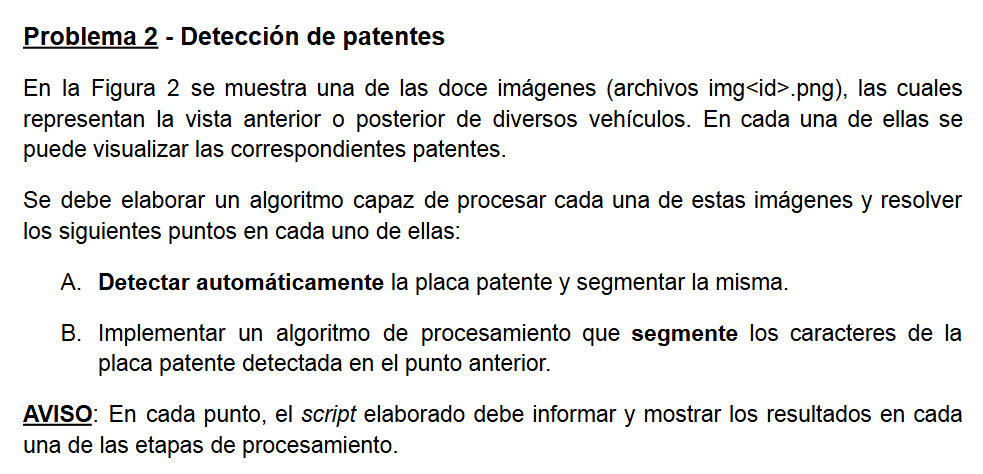

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

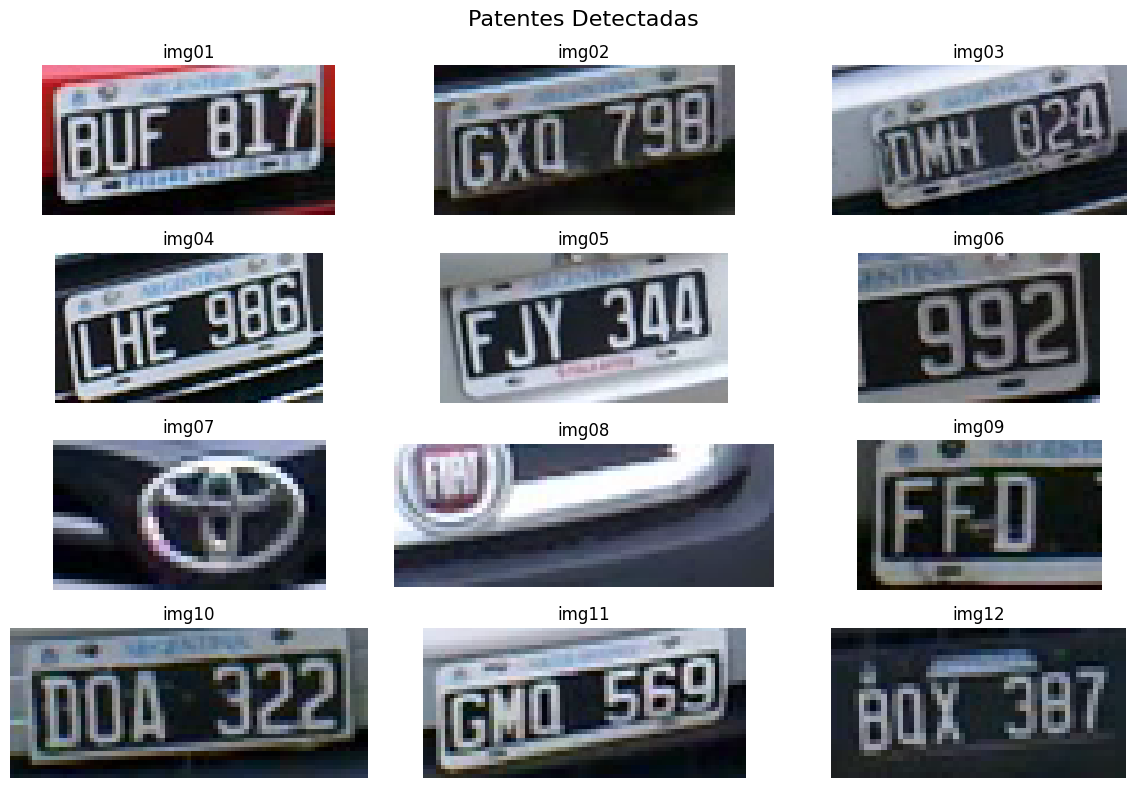

In [ ]:
def obtener_recorte_patente(path):
    img = cv2.imread(path)
    if img is None: return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13, 5))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    thresh = cv2.threshold(blackhat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    #candidatos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidatos = []

    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / h
        
        if 1.5 < aspect < 3.5 and w*h > 20 and 15 < h < 40:
            candidatos.append((x, y, w, h))

    if not candidatos: 
        return None

    H, W = img.shape[:2]
    
    #seleccion
    def calcular_puntaje(r):
        x, y, w, h = r
        
        #Centrado Horizontal
        center_x = x + w//2
        dist_center_x = abs(W//2 - center_x)
        
        if dist_center_x < W * 0.15: s_center_x = 15 
        elif dist_center_x < W * 0.35: s_center_x = 5
        else: s_center_x = -5 
            
        #Proporcion
        aspect = w / h
        s_aspect = max(0, 15 - abs(aspect - 2.75) * 5)
        
        #Posición Vertical
        center_y = y + h//2
        s_pos_y = 5 if 0.30 * H < center_y < 0.85 * H else -5

        #Tamaño
        area = w * h
        s_size = 5 if area > (W*H)*0.005 else 0

        return s_center_x + s_aspect + s_pos_y + s_size

    ganador = max(candidatos, key=calcular_puntaje)
    x, y, w, h = ganador

    pad = 5
    recorte = img[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]

    return recorte




resultados_crops = []
nombres_archivos = []

for i in range(1, 13):
    nombre_archivo = f'img/img{i:02d}.png' 
    recorte = obtener_recorte_patente(nombre_archivo)
    resultados_crops.append(recorte)
    nombres_archivos.append(f"img{i:02d}")


fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle('Patentes Detectadas', fontsize=16)

axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(resultados_crops):
        img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(nombres_archivos[i])
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def segmentar_caracteres(img_patente):
    if img_patente is None: return []

 
    gray = cv2.cvtColor(img_patente, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    H, W = thresh.shape

    #contornos
    cnts, _ = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    
    caracteres_candidatos = []
    
    for c in cnts:
        x, y, w, h = cv2.boundingRect(c)
        aspect_ratio = w / float(h)
        area = w * h
        img_area = W * H

        keep_h = 0.20 < h / H < 0.95 
        keep_w = 0.02 < w / W < 0.25 
        keep_ratio = 0.1 < aspect_ratio < 1.1 

        keep_area = area > img_area * 0.03

        if keep_h and keep_ratio and keep_area and keep_w:
            caracteres_candidatos.append((x, y, w, h))

    caracteres_candidatos = sorted(caracteres_candidatos, key=lambda c: c[0])

    chars_imgs = []
    pad = 2 
    for (x, y, w, h) in caracteres_candidatos:
        roi = img_patente[max(0, y-pad):min(H, y+h+pad), max(0, x-pad):min(W, x+w+pad)]
        chars_imgs.append(roi)

    return chars_imgs

Procesando 12 recortes de patentes...


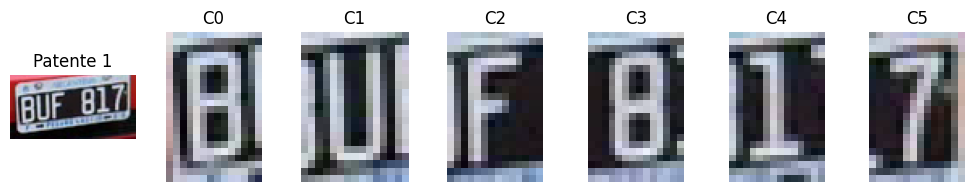

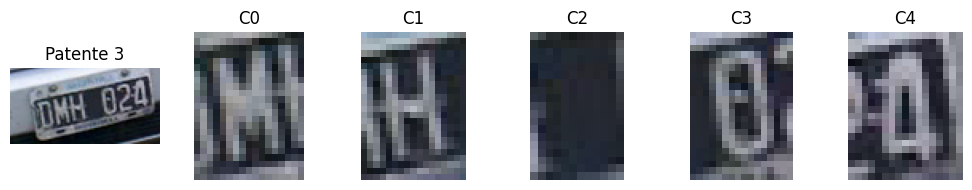

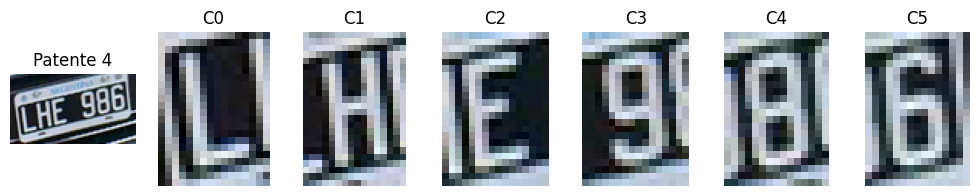

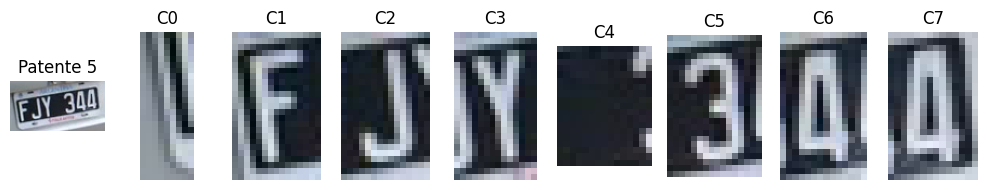

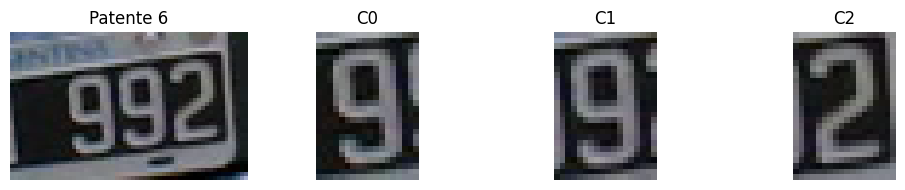

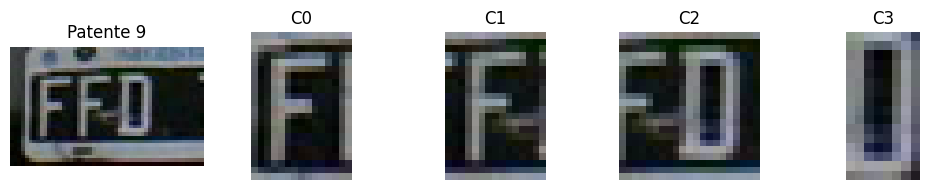

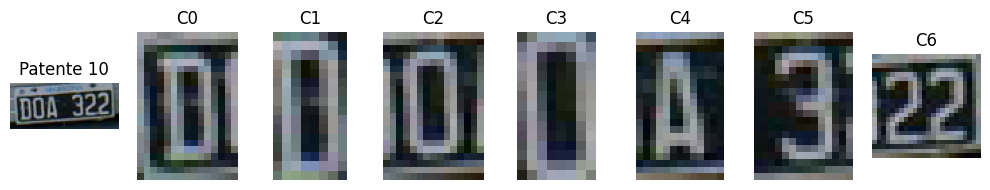

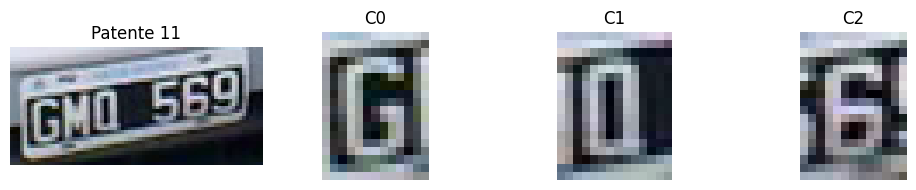

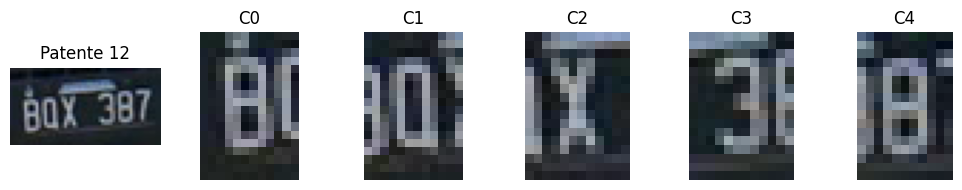

In [ ]:
todas_las_patentes_segmentadas = []

print(f"Procesando {len(resultados_crops)} recortes de patentes...")

for i, recorte_patente in enumerate(resultados_crops):
    if recorte_patente is None:
        todas_las_patentes_segmentadas.append([])
        continue
        
    chars = segmentar_caracteres(recorte_patente)
    todas_las_patentes_segmentadas.append(chars)



for i, chars in enumerate(todas_las_patentes_segmentadas):

    if len(chars) < 3: continue 

    plt.figure(figsize=(10, 2))
    
    plt.subplot(1, len(chars) + 1, 1)
    img_rgb = cv2.cvtColor(resultados_crops[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Patente {i+1}")
    plt.axis('off')
    
    for j, char_img in enumerate(chars):
        plt.subplot(1, len(chars) + 1, j + 2)
        char_rgb = cv2.cvtColor(char_img, cv2.COLOR_BGR2RGB)
        plt.imshow(char_rgb)
        plt.title(f"C{j}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()